📚 Step 1: Import Required Libraries

In [1]:
import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()


In [3]:
# Import Required Libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Enable Mixed Precision for Faster Training
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Check GPU availability
print(f"✅ Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")


✅ Num GPUs Available: 1


📂 Step 2: Mount Google Drive & Set Dataset Path

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define Dataset Path in Google Drive
DATASET_PATH = '/content/drive/MyDrive/wheat'  # Update if needed


Mounted at /content/drive


📊 Step 3: Data Preprocessing & Augmentation

In [5]:
# Define image size and batch size
IMG_SIZE = (150, 150)  # Reduced image size for faster training
BATCH_SIZE = 64  # Increased batch size for fewer steps

# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

# Training Set
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Set
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Class Labels
class_indices = train_generator.class_indices
print(f"✅ Class Indices: {class_indices}")


Found 2355 images belonging to 3 classes.
Found 587 images belonging to 3 classes.
✅ Class Indices: {'healthy': 0, 'septoria': 1, 'stripe_rust': 2}


🧠 Step 4: Load Pre-trained VGG16 Model (Transfer Learning)

In [6]:
# Load Pre-trained VGG16 Model + Higher Level Layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze Pre-trained Layers (do not train them)
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Layers on Top of VGG16
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
output_layer = Dense(3, activation='softmax')(x)

# Define Final Model
model = Model(inputs=base_model.input, outputs=output_layer)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


⚙️ Step 5: Compile the Model

In [7]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show Model Summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast (Cast)                          │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 15,771,843 (60.16 MB)

 Trainable params: 1,057,155 (4.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

🎯 Step 6: Add Early Stopping & Fit the Model

In [8]:
# Add Early Stopping to Reduce Unnecessary Epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Stop if no improvement for 3 consecutive epochs
    restore_best_weights=True
)

# Define Number of Epochs
EPOCHS = 15  # Reduced epochs due to transfer learning

# Fit the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=[early_stopping]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 490s 13s/step - accuracy: 0.5112 - loss: 1.0326 - val_accuracy: 0.7768 - val_loss: 0.6023
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7964 - loss: 0.5503 - val_accuracy: 0.9302 - val_loss: 0.2644
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8423 - loss: 0.4054 - val_accuracy: 0.8910 - val_loss: 0.2914
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8677 - loss: 0.3513 - val_accuracy: 0.9029 - val_loss: 0.2555
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8995 - loss: 0.2971 - val_accuracy: 0.9574 - val_loss: 0.1474
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8821 - loss: 0.3185 - val_accuracy: 0.9387 - val_loss: 0.1614
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8980 - loss: 0.2643 - val_accuracy: 0.9404 - val_loss: 0.1703
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9000 - loss: 0.2560 - val_accuracy: 0.9608 - val_los

📈 Step 7: Evaluate the Model

In [9]:
# Evaluate Model on Validation Set
val_loss, val_acc = model.evaluate(val_generator)
print(f"✅ Validation Accuracy: {val_acc:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 681ms/step - accuracy: 0.9556 - loss: 0.1260
✅ Validation Accuracy: 0.9472


📊 Step 8: Plot Accuracy & Loss Curves

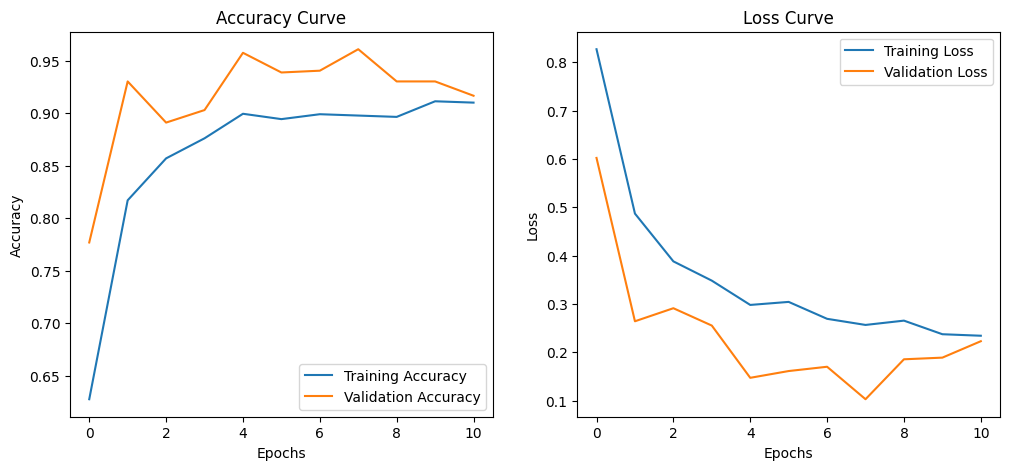

In [10]:
# Plot Accuracy and Loss Curves
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    plt.show()

plot_history(history)


🧪 Step 9: Evaluate on Test Data

In [12]:
# Load Test Set (Optional if you have test data)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/wheat',  # Path to test data
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get Predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Classification Report
print(classification_report(true_classes, predicted_classes, target_names=list(class_indices.keys())))

# Confusion Matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print(conf_matrix)


Found 2942 images belonging to 3 classes.
46/46 ━━━━━━━━━━━━━━━━━━━━ 32s 677ms/step
              precision    recall  f1-score   support

     healthy       0.93      0.98      0.95      1116
    septoria       0.94      0.92      0.93       902
 stripe_rust       0.96      0.93      0.95       924

    accuracy                           0.94      2942
   macro avg       0.95      0.94      0.94      2942
weighted avg       0.95      0.94      0.94      2942

[[1089   24    3]
 [  42  831   29]
 [  37   27  860]]


💾 Step 10: Save the Model

In [13]:
# Save the Model to Google Drive
MODEL_PATH = '/content/drive/MyDrive/wheat_cnn_model.h5'
model.save(MODEL_PATH)
print(f"✅ Model Saved Successfully at {MODEL_PATH}")


✅ Model Saved Successfully at /content/drive/MyDrive/wheat_cnn_model.h5


In [19]:
# Import Required Libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.layers import Layer


In [20]:
# Define a dummy Cast layer to handle custom objects from mixed precision
class Cast(Layer):
    def call(self, inputs):
        return tf.cast(inputs, tf.float16)

# Register the Cast layer as a custom object
get_custom_objects().update({'Cast': Cast})


In [29]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define Dataset Path and Model Path
DATASET_PATH = '/content/drive/MyDrive/wheat'  # Path to dataset
MODEL_PATH = '/content/drive/MyDrive/wheat_cnn_model.h5'  # Model path

# Define Path to Test Image from 'healthy' Folder
img_path = '/content/drive/MyDrive/wheat/stripe_rust/Yellow_rust1144.jpg'  # Change the image name if needed

# Check if the image exists
if os.path.exists(img_path):
    print(f"✅ Image found: {img_path}")
else:
    print(f"❌ Image not found. Check the path again!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Image found: /content/drive/MyDrive/wheat/stripe_rust/Yellow_rust1144.jpg


In [30]:
# Load the model with custom object handling
try:
    model = load_model(MODEL_PATH, custom_objects={'Cast': Cast})
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {str(e)}")


✅ Model loaded successfully!


In [31]:
from tensorflow.keras.preprocessing import image

# Load the image and resize it to 150x150 (same as training data)
IMG_SIZE = (150, 150)
img = image.load_img(img_path, target_size=IMG_SIZE)

# Convert image to array and normalize
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize pixel values to [0, 1]

print("✅ Image loaded and preprocessed successfully!")


✅ Image loaded and preprocessed successfully!


In [32]:
# Predict class of the image
predictions = model.predict(img_array)

# Get the predicted class with highest probability
predicted_class = np.argmax(predictions, axis=1)[0]

# Class Labels (Manually Map Them Since Train Generator is Not Available)
class_labels = {0: 'healthy', 1: 'septoria', 2: 'stripe_rust'}

# Get Predicted Class Label
predicted_label = class_labels[predicted_class]

print(f"✅ Predicted Class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
✅ Predicted Class: stripe_rust


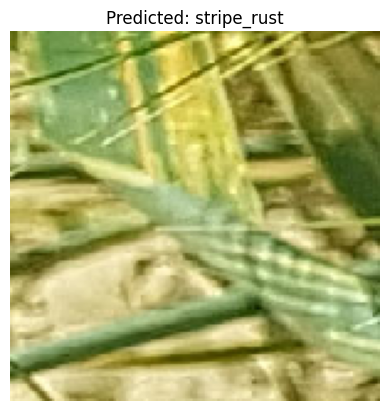

In [33]:
# Plot and Display the Image with Prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [ ]:

# Convert the trained model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("wheat_disease_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model successfully converted to TensorFlow Lite format: wheat_disease_model.tflite")
